In [ ]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData

data = csvFuturesSimData()


In [ ]:
data.get_instrument_list()


['FTSECHINAH',
 'EU-MID',
 'EU-DIV30',
 'JP-REALESTATE',
 'SMI',
 'DJSTX-SMALL',
 'LUMBER-new',
 'EUROSTX200-LARGE',
 'CAD5',
 'PALLAD',
 'HIGHYIELD',
 'GBPEUR',
 'SP500_micro',
 'BOVESPA',
 'IRON',
 'LEANHOG',
 'GAS-LAST',
 'US-STAPLES',
 'ETHER-micro',
 'WHEAT_ICE',
 'VNKI',
 'SOYBEAN',
 'EU-DJ-UTIL',
 'FTSEINDO',
 'NZD',
 'ETHANOL',
 'GOLD',
 'MSCIASIA',
 'BB3M',
 'CAD2',
 'EU-DJ-TECH',
 'JPY_mini',
 'EU-TECH',
 'MIB',
 'SMI-MID',
 'GILT',
 'BTP',
 'EU-TRAVEL',
 'MSCIWORLD',
 'SWISSLEAD',
 'SOYBEAN_mini',
 'KRWUSD_mini',
 'STEEL',
 'HANGTECH',
 'NASDAQ_micro',
 'ROBUSTA',
 'VIX_mini',
 'CAD10',
 'AEX',
 'BBCOMM',
 'NASDAQ',
 'EU-HOUSE',
 'HOUSE-US',
 'NIKKEI400',
 'RUSSELL',
 'GASOILINE_micro',
 'EURIBOR-ICE',
 'CANOLA',
 'EU-HEALTH',
 'HEATOIL-ICE',
 'MSCIEAFA',
 'SUGAR16',
 'SILVER',
 'EUA',
 'COPPER-micro',
 'CHEESE',
 'CAD_micro',
 'EURCHF',
 'GAS-PEN',
 'MILKWET',
 'CAC',
 'CHF_micro',
 'GASOIL',
 'AUD',
 'EU-CHEM',
 'EU-DJ-OIL',
 'BUND',
 'EU-FOOD',
 'US-MATERIAL',
 'US10',
 '

In [ ]:
data.keys()
data['SP500_micro']


index
1982-09-14 23:00:00     679.40
1982-09-15 23:00:00     679.90
1982-09-16 23:00:00     679.25
1982-09-17 23:00:00     678.35
1982-09-20 23:00:00     679.15
                        ...   
2024-03-28 17:00:00    5309.25
2024-03-28 18:00:00    5316.50
2024-03-28 19:00:00    5305.50
2024-03-28 20:00:00    5306.00
2024-03-28 23:00:00    5303.75
Name: price, Length: 35898, dtype: float64

In [ ]:
import pandas as pd
from sysquant.estimators.vol import robust_vol_calc

def calc_ewmac_forecast(price, Lfast, Lslow=None):
    
    price = price.resample("1B").last()
    if Lslow is None:
        Lslow = 4 * Lfast
    
    fast_ewma = price.ewm(span=Lfast).mean()
    slow_ewma = price.ewm(span=Lslow).mean()
    raw_ewmac = fast_ewma - slow_ewma
    
    vol = robust_vol_calc(price.diff())
    
    return raw_ewmac / vol


In [ ]:
instrument_code = "SP500_micro"
price = data.daily_prices(instrument_code)
ewmac = calc_ewmac_forecast(price, 32, 128)
ewmac.tail(5)


index
2024-03-22    8.367249
2024-03-25    8.575964
2024-03-26    8.771066
2024-03-27    8.856622
2024-03-28    9.108725
Freq: B, Name: price, dtype: float64

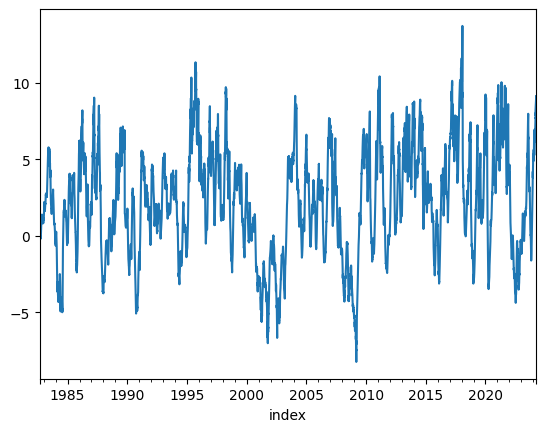

In [ ]:
from matplotlib.pyplot import show
ewmac.plot()
show()


In [31]:
from sysdata.sim.csv_futures_sim_data import csvFuturesSimData
data = csvFuturesSimData

from systems.provided.rules.ewmac import ewmac_forecast_with_defaults as ewmac


In [32]:
from systems.forecasting import Rules
my_rules = Rules(ewmac)
my_rules.trading_rules()


{'rule0': TradingRule; function: <function ewmac_forecast_with_defaults at 0x138074160>, data: data.daily_prices (args: {}) and other_args: }

In [33]:
my_rules=Rules(dict(ewmac=ewmac))
my_rules.trading_rules()


{'ewmac': TradingRule; function: <function ewmac_forecast_with_defaults at 0x138074160>, data: data.daily_prices (args: {}) and other_args: }

In [34]:
from systems.basesystem import System
my_system=System([my_rules], data)
my_system


Private configuration '/Users/jasonli/Dev/FORKed repo/pysystemtrade/private/private_config.yaml' is missing or misconfigured; no problem if running in sim mode


TypeError: simData.system_init() missing 1 required positional argument: 'base_system'